# Seminar 3 - Problem statement

## 1. Part I: Data preparation & analysis

The dataset for this seminar (dataset Seminar3.zip) contains two files:

1. **rssi_data.csv**: Wi-Fi RSSI measurements taken at K = 3 different APs (AP1, AP2, and AP3), for P = 5 positions in which the STA was placed. In each row, there is the RSSI perceived by each of the APs for a single measurement. The dataset includes M = 300 measurements per location p ∈ P, thus it contains (P × M) × K values.

2. **labels_data.csv**: The ground truth (i.e., the real position of the STA) for each measurement. (P × M) values are provided.

Once you load the data into your workspace, process it to provide the following plots:

• 2-D plots showing the RSSI perceived by each pair of APs (e.g., AP1 vs AP2).

• A 3-D plot showing the RSSI perceived by each of the APs.

Apart from that, describe the statistics behind each of the considered points. For that, compute the average RSSI and the standard deviation obtained in each of the 5 studied locations. Plot the results.

## 2. Part II: K-Means implementation

Implement a simple K-Means algorithm (by hand) that performs the following operations:

• Initializes the centroids randomly in 3D space.

• Iteratively updates the centroids by following these two steps:
  - Assign each point in the dataset to a centroid by calculating the Euclidean distance between the point and each centroid. The selected centroid should be the one that is closest in distance to the point.
  - Update the centroid of each cluster as the mean position of the points in that cluster.¹

• Check if the algorithm has converged. For that, establish two conditions:
  - The assignment of clusters to each point in the dataset does not vary from one iteration to another.
  - A maximum number of iterations (T = 100) is reached.

Once your K-Means implementation is ready, use it in the Wi-Fi fingerprinting dataset to determine the location of each point. Compare the results with the ground truth and plot the results.


#### **Core libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import mode

# **Part I**

#### **Load all data from the datasets**

In [2]:
rssi = pd.read_csv('rssi_data.csv', header=None, names=['AP1', 'AP2', 'AP3'])
labels = pd.read_csv('labels_data.csv', header=None, names=['location'])
df = pd.concat([rssi, labels], axis=1)

### **2-D plots showing the RSSI perceived by each pair of APs (e.g., AP1 vs AP2)**

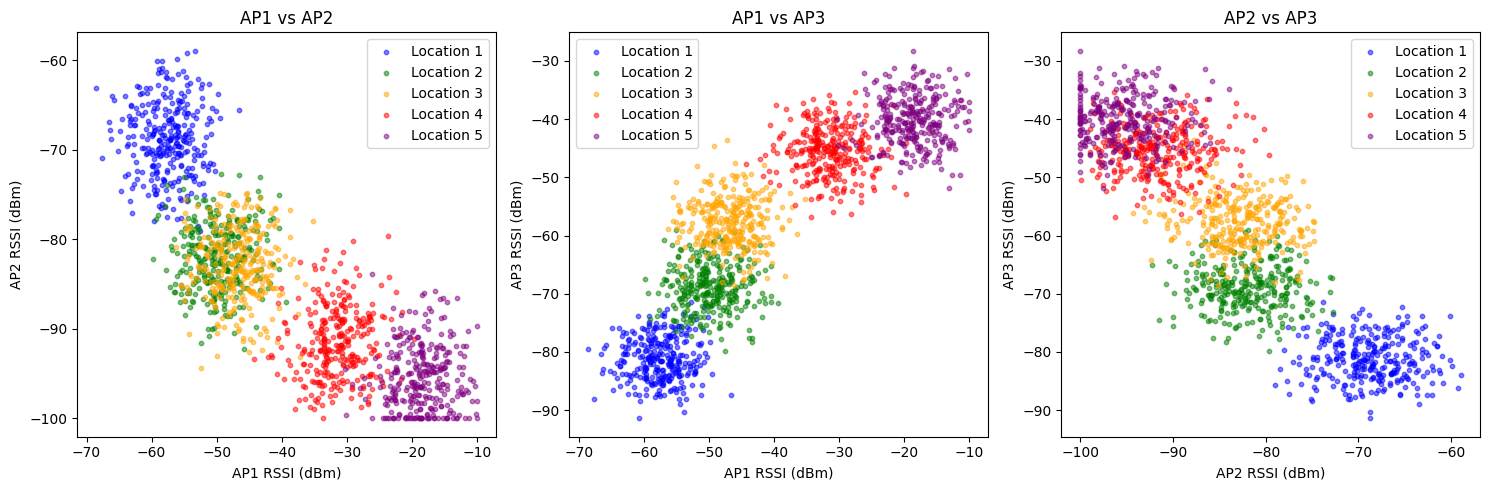

In [3]:
colors = {1: 'blue', 2: 'green', 3: 'orange', 4: 'red', 5: 'purple'}
pairs = [('AP1', 'AP2'), ('AP1', 'AP3'), ('AP2', 'AP3')]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (apx, apy) in zip(axes, pairs):
    for loc in sorted(df['location'].unique()):
        subset = df[df['location'] == loc]
        ax.scatter(subset[apx], subset[apy], label=f'Location {loc}',
                   color=colors[loc], alpha=0.5, s=10)
    ax.set_xlabel(f'{apx} RSSI (dBm)')
    ax.set_ylabel(f'{apy} RSSI (dBm)')
    ax.set_title(f'{apx} vs {apy}')
    ax.legend()

plt.tight_layout()
plt.show()

##### **Explication:** Each dot is one measurement, colored by location. The 5 clusters are separated in all three pair combinations, meaning the RSSI values alone are enough to distinguish locations. AP1 vs AP2 shows the clearest separation, as you move closer to AP1 (stronger signal), AP2 gets weaker, which reflects the physical distance from each AP.

### **A3-D plot showing the RSSI perceived by each of the APs.**

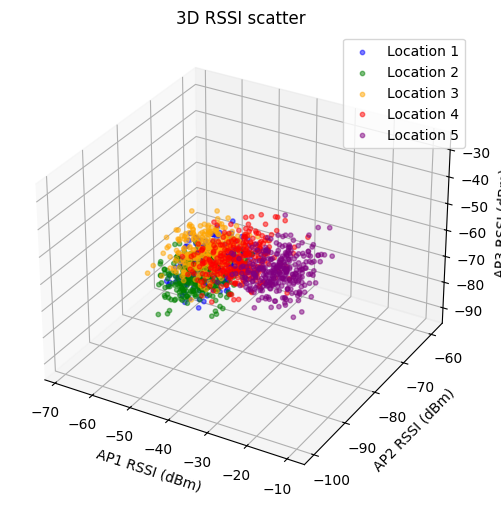

In [4]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for loc in sorted(df['location'].unique()):
    subset = df[df['location'] == loc]
    ax.scatter(subset['AP1'], subset['AP2'], subset['AP3'],
               label=f'Location {loc}', color=colors[loc], alpha=0.5, s=10)

ax.set_xlabel('AP1 RSSI (dBm)')
ax.set_ylabel('AP2 RSSI (dBm)')
ax.set_zlabel('AP3 RSSI (dBm)')
ax.set_title('3D RSSI scatter')
ax.legend()
plt.show()

##### **Explication:** Same data but in 3D. You can see the 5 clusters occupy distinct regions in the 3D RSSI space. Locations 4 and 5 (red/purple) are very separated from the rest since they are close to AP1 and far from AP2. 

### **Description of statistics behind each of the considered points.**

#### Mean and std per location per AP


In [5]:
stats = df.groupby('location')[['AP1', 'AP2', 'AP3']].agg(['mean', 'std'])
print(stats)

                AP1                  AP2                  AP3          
               mean       std       mean       std       mean       std
location                                                               
1        -57.547793  3.676167 -68.772187  4.041594 -81.156930  3.748209
2        -49.811667  3.892066 -81.979633  3.760133 -68.978473  3.869161
3        -46.740827  3.951756 -82.877667  3.981708 -57.633320  4.141495
4        -31.584760  4.058027 -91.492630  3.944587 -45.475647  4.102736
5        -18.477953  3.860880 -95.344790  3.531129 -40.081403  4.128701


##### **Explication:** Each row is a location. As the location number increases, AP1 mean RSSI increases (gets stronger, from −57.5 to −18.5 dBm) while AP2 becomes weaker (from −68.8 to −95.3 dBm). AP3 also increases from −81.2 to −40.1. The std is consistently around 3.5–4.1 dBm for all locations and APs, meaning the measurements are very stable and compact clusters.

#### Plot of the statistics

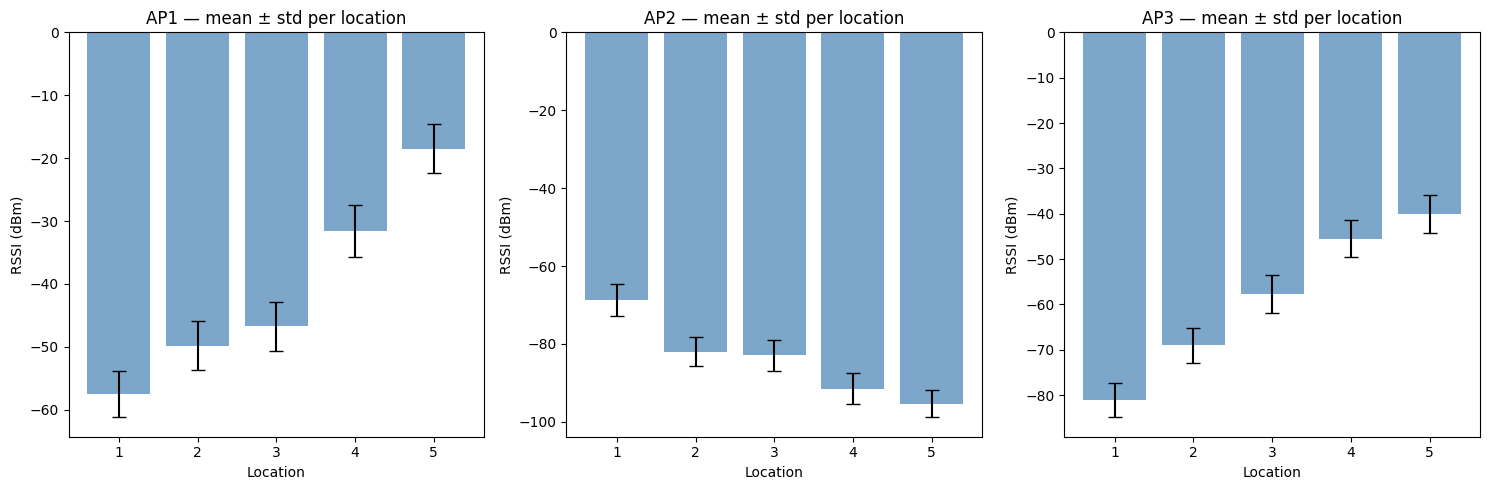

In [6]:
locations = sorted(df['location'].unique())
aps = ['AP1', 'AP2', 'AP3']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, ap in zip(axes, aps):
    means = [df[df['location'] == loc][ap].mean() for loc in locations]
    stds  = [df[df['location'] == loc][ap].std()  for loc in locations]
    ax.bar(locations, means, yerr=stds, capsize=5, color='steelblue', alpha=0.7)
    ax.set_xlabel('Location')
    ax.set_ylabel('RSSI (dBm)')
    ax.set_title(f'{ap} — mean ± std per location')
    ax.set_xticks(locations)

plt.tight_layout()
plt.show()

##### **Explication:** Visual representation of the table above. The error bars (std) are small and don't overlap between locations, which visually confirms that the clusters are well-separated and K-Means should have no trouble distinguishing them.

# **Part II**

### 1. K-Means implementation from scratch

In [7]:
def kmeans(X, K=5, max_iter=100):
    # Random centroid initialization
    rng = np.random.default_rng(seed=42)
    idx = rng.choice(len(X), size=K, replace=False)
    centroids = X[idx].copy()

    assignments = np.zeros(len(X), dtype=int)

    for iteration in range(max_iter):
        # Step 1: Assign each point to the nearest centroid
        new_assignments = np.zeros(len(X), dtype=int)
        for i, point in enumerate(X):
            distances = [np.sqrt(np.sum((point - c) ** 2)) for c in centroids]
            new_assignments[i] = np.argmin(distances)

        # Step 2: Check convergence (assignments didn't change)
        if np.array_equal(new_assignments, assignments):
            print(f"Converged at iteration {iteration}")
            break
        assignments = new_assignments

        # Step 3: Update centroids
        for k in range(K):
            cluster_points = X[assignments == k]
            if len(cluster_points) == 0:
                # Re-initialize empty cluster randomly
                centroids[k] = X[rng.choice(len(X))]
            else:
                centroids[k] = cluster_points.mean(axis=0)

    return assignments, centroids

##### **Explication:**  First, K-means basically chooses 5 random centroids as the objective is to create 5 clusters. Then, each data point is assigned to the closest centroid, and after that, the centroids move to the average position of the points assigned to them. This is repeated until the points stop changing clusters. Therfore, if that happens, it means that the algorithm has converged.

### 2. Run K-Means on the dataset

In [8]:
X = df[['AP1', 'AP2', 'AP3']].values

cluster_assignments, final_centroids = kmeans(X, K=5, max_iter=100)

Converged at iteration 28


##### **Explication:** The result says it converged at iteration 28, meaning the clusters became stable after 28 repetitions.

### 3. Compare with ground truth
K-Means assigns arbitrary cluster IDs (0–4), which may not match the location labels (1–5). We need to map them by finding the best match:

In [9]:
# For each cluster, find the most common true label
label_map = {}
for k in range(5):
    true_labels = df['location'].values[cluster_assignments == k]
    most_common = mode(true_labels, keepdims=True).mode[0]
    label_map[k] = most_common

# Map cluster assignments to predicted locations
predicted_locations = np.array([label_map[k] for k in cluster_assignments])

# Accuracy
accuracy = np.mean(predicted_locations == df['location'].values)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 95.93%


##### **Explication:** K-Means does not know the real location names. It only creates cluster numbers like 0, 1, 2, 3, and 4. Therefore, each cluster must be matched with the real location that appears most often inside it. After this mapping, the predictions are compared with the real labels. The accuracy is 95.93%, so the model predicts the correct location almost 96% of the time.

### 4. Plot predicted vs ground truth (2D)

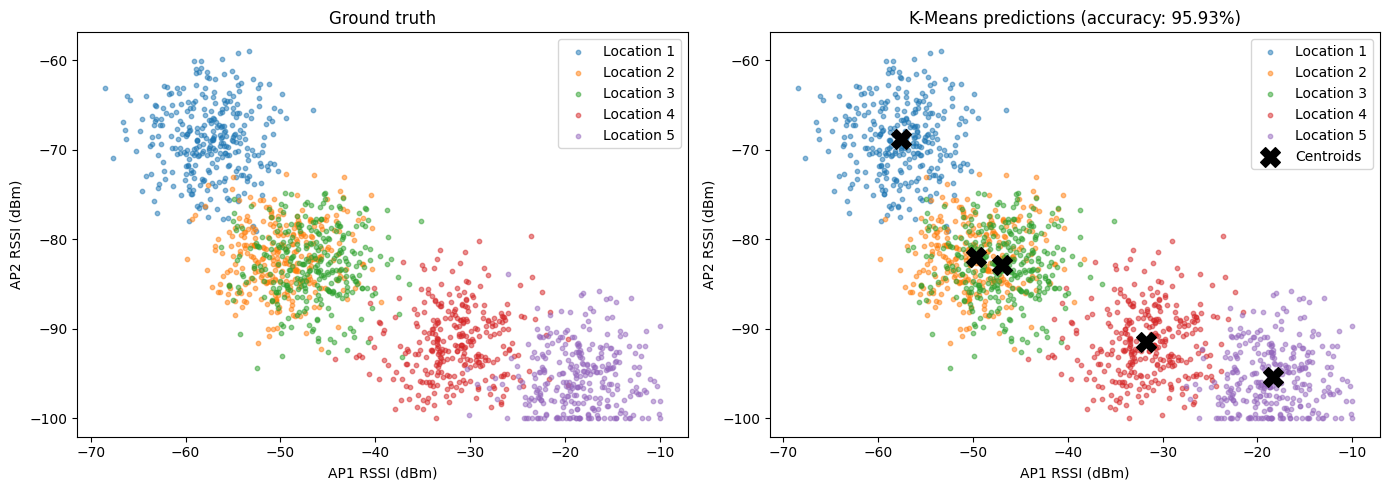

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ground truth
for loc in sorted(df['location'].unique()):
    mask = df['location'].values == loc
    axes[0].scatter(X[mask, 0], X[mask, 1], label=f'Location {loc}',
                    alpha=0.5, s=10)
axes[0].set_title('Ground truth')
axes[0].set_xlabel('AP1 RSSI (dBm)')
axes[0].set_ylabel('AP2 RSSI (dBm)')
axes[0].legend()

# K-Means predictions
for loc in sorted(df['location'].unique()):
    mask = predicted_locations == loc
    axes[1].scatter(X[mask, 0], X[mask, 1], label=f'Location {loc}',
                    alpha=0.5, s=10)
# Plot centroids
axes[1].scatter(final_centroids[:, 0], final_centroids[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[1].set_title(f'K-Means predictions (accuracy: {accuracy*100:.2f}%)')
axes[1].set_xlabel('AP1 RSSI (dBm)')
axes[1].set_ylabel('AP2 RSSI (dBm)')
axes[1].legend()

plt.tight_layout()
plt.show()

##### **Explication:** The left graph shows the real locations using AP1 and AP2 RSSI values. The right graph shows the locations predicted by K-Means. The black crosses are the centroids, which are the centers of the clusters. Since both graphs look very similar, the model has learned the location groups well. The small errors happen where some locations overlap and have similar signal values.

### 5. Plot predicted vs ground truth (3D)

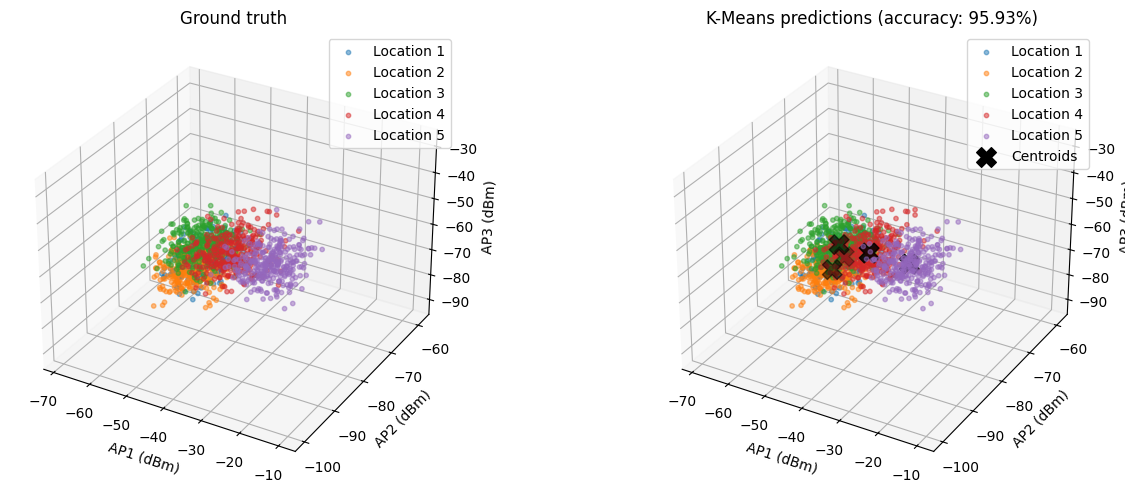

In [11]:
fig = plt.figure(figsize=(14, 5))

# Ground truth
ax1 = fig.add_subplot(121, projection='3d')
for loc in sorted(df['location'].unique()):
    mask = df['location'].values == loc
    ax1.scatter(X[mask, 0], X[mask, 1], X[mask, 2],
                label=f'Location {loc}', alpha=0.5, s=10)
ax1.set_title('Ground truth')
ax1.set_xlabel('AP1 (dBm)')
ax1.set_ylabel('AP2 (dBm)')
ax1.set_zlabel('AP3 (dBm)')
ax1.legend()

# K-Means predictions
ax2 = fig.add_subplot(122, projection='3d')
for loc in sorted(df['location'].unique()):
    mask = predicted_locations == loc
    ax2.scatter(X[mask, 0], X[mask, 1], X[mask, 2],
                label=f'Location {loc}', alpha=0.5, s=10)
ax2.scatter(final_centroids[:, 0], final_centroids[:, 1], final_centroids[:, 2],
            c='black', marker='X', s=200, zorder=5, label='Centroids')
ax2.set_title(f'K-Means predictions (accuracy: {accuracy*100:.2f}%)')
ax2.set_xlabel('AP1 (dBm)')
ax2.set_ylabel('AP2 (dBm)')
ax2.set_zlabel('AP3 (dBm)')
ax2.legend()

plt.tight_layout()
plt.show()

##### **Explication:** The 3D plot gives more information than the 2D plot because it includes the third access point. The result is still very good, with 95.93% accuracy, showing that RSSI signals are useful to estimate the user’s location.